# Diagnostyka cech logitowych i funkcji `score`

Notebook odpowiada na trzy pytania: kiedy w warstwach pojawia się poprawna prognoza, które cechy najlepiej rozdzielają odpowiedzi poprawne i błędne oraz jak wygląda oszacowana funkcja `s(x)`. Logika wczytywania danych znajduje się w `src.analysis.diagnostic_results`; tutaj pozostają tylko jawne agregacje i wykresy.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir()), Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.analysis.diagnostic_results import attach_score_values, load_all_diagnostic_runs
from src.analysis.run_discovery import FEATURE_LABELS, MODEL_ORDER, apply_model_order

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.unicode_minus': False})
pd.set_option('display.max_columns', 60)

In [2]:
runs = load_all_diagnostic_runs()
overview = apply_model_order(pd.DataFrame([
    {
        'model': run['label'],
        'warstwy': run['max_layer'],
        'fit_n': len(run['fit_clean']),
        'eval_n': len(run['eval_clean']),
        'accuracy_fit': run['fit_clean']['clean_is_correct'].mean(),
        'accuracy_eval': run['eval_clean']['clean_is_correct'].mean(),
    }
    for run in runs
]))
display(overview.round(3))

,model,warstwy,fit_n,eval_n,accuracy_fit,accuracy_eval
0,Qwen 0.5B,24,9741,1221,0.543,0.541
1,Qwen 3B,36,9741,1221,0.774,0.803
2,Qwen 7B,28,9741,1221,0.821,0.825
3,Llama 1B,16,9741,1221,0.508,0.527
4,Llama 3B,28,9741,1221,0.638,0.670


## Prognozy warstwowe

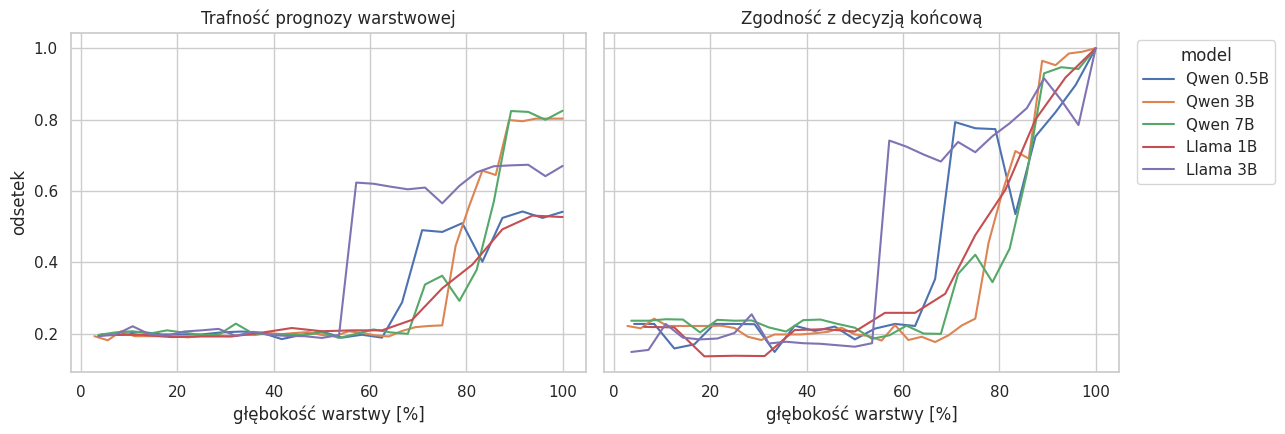

In [3]:
layerwise = pd.concat([
    run['eval_layerwise'].assign(
        model=run['label'],
        layer_pct=100 * run['eval_layerwise']['layer_number'] / run['max_layer'],
    )
    for run in runs
], ignore_index=True)
layer_summary = layerwise.groupby(['model', 'layer_number', 'layer_pct'], observed=True).agg(
    layer_accuracy=('layer_is_correct', 'mean'),
    agreement_with_final=('matches_final_prediction', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for metric, title, ax in [
    ('layer_accuracy', 'Trafność prognozy warstwowej', axes[0]),
    ('agreement_with_final', 'Zgodność z decyzją końcową', axes[1]),
]:
    sns.lineplot(data=layer_summary, x='layer_pct', y=metric, hue='model', hue_order=MODEL_ORDER, ax=ax)
    ax.set(title=title, xlabel='głębokość warstwy [%]', ylabel='odsetek')
axes[1].legend(title='model', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].legend_.remove()
plt.tight_layout()

## Separacja odpowiedzi poprawnych i błędnych

,model,feature,selection_rank,layer_number,layer_pct,ks_statistic
0,Qwen 0.5B,entropia odpowiedzi,1,24,100.000,0.319
1,Qwen 0.5B,entropia odpowiedzi,2,22,91.667,0.316
2,Qwen 0.5B,entropia odpowiedzi,3,23,95.833,0.299
3,Qwen 0.5B,entropia odpowiedzi,4,21,87.500,0.261
4,Qwen 0.5B,entropia odpowiedzi,5,19,79.167,0.236
...,...,...,...,...,...,...
115,Llama 3B,varentropy odpowiedzi,4,28,100.000,0.268
116,Llama 3B,varentropy odpowiedzi,5,22,78.571,0.213
117,Llama 3B,varentropy odpowiedzi,6,25,89.286,0.204
118,Llama 3B,varentropy odpowiedzi,7,27,96.429,0.180


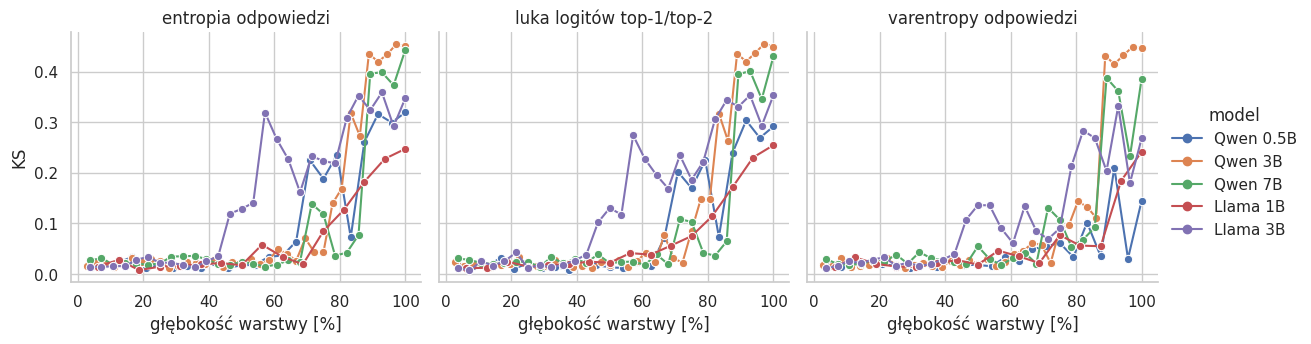

In [4]:
separation = apply_model_order(pd.concat([run['separation'] for run in runs], ignore_index=True))
top_layers = apply_model_order(pd.concat([
    run['selected'].query('selection_rank <= 8') for run in runs
], ignore_index=True))
display(top_layers[[
    'model', 'feature', 'selection_rank', 'layer_number', 'layer_pct', 'ks_statistic'
]].sort_values(['feature', 'model', 'selection_rank']).round(3))

g = sns.relplot(
    data=separation, x='layer_pct', y='ks_statistic',
    hue='model', hue_order=MODEL_ORDER, col='feature', col_wrap=3,
    kind='line', marker='o', height=3.6, aspect=1.1,
)
g.set_axis_labels('głębokość warstwy [%]', 'KS')
g.set_titles('{col_name}')

## Rozkłady cech w najlepiej separujących warstwach

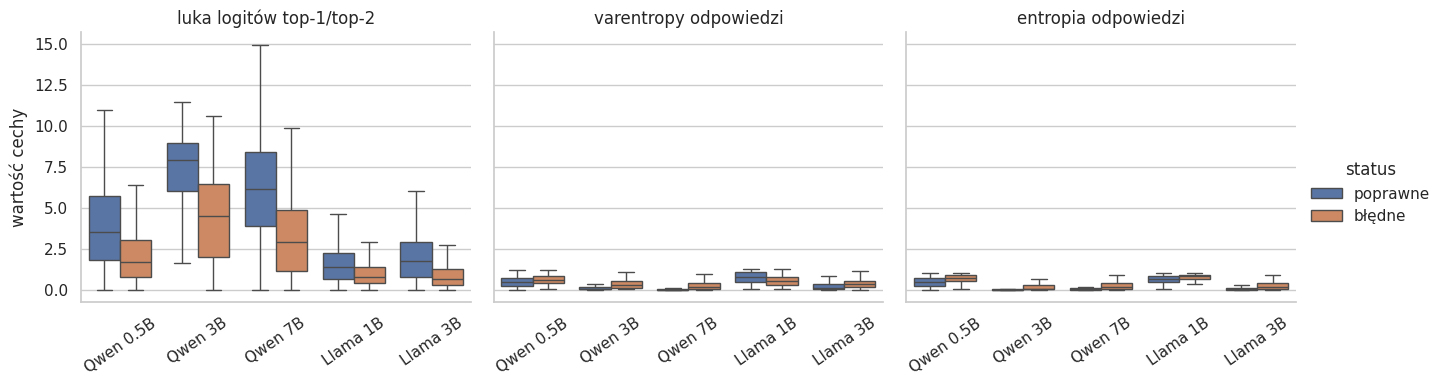

In [5]:
top_values = []
for run in runs:
    selected = run['selected'].query('selection_rank == 1')[['feature_name', 'layer_number']]
    values = run['eval_values'].merge(selected, on=['feature_name', 'layer_number'], how='inner')
    values['model'] = run['label']
    values['status'] = values['clean_is_correct'].map({True: 'poprawne', False: 'błędne'})
    top_values.append(values)
top_values = apply_model_order(pd.concat(top_values, ignore_index=True))

g = sns.catplot(
    data=top_values, x='model', y='feature_value', hue='status',
    col='feature', col_wrap=3, kind='box', showfliers=False,
    height=3.8, aspect=1.15,
)
g.set_axis_labels('', 'wartość cechy')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=35)

## Przykład dopasowanych gęstości i funkcji `s(x)`

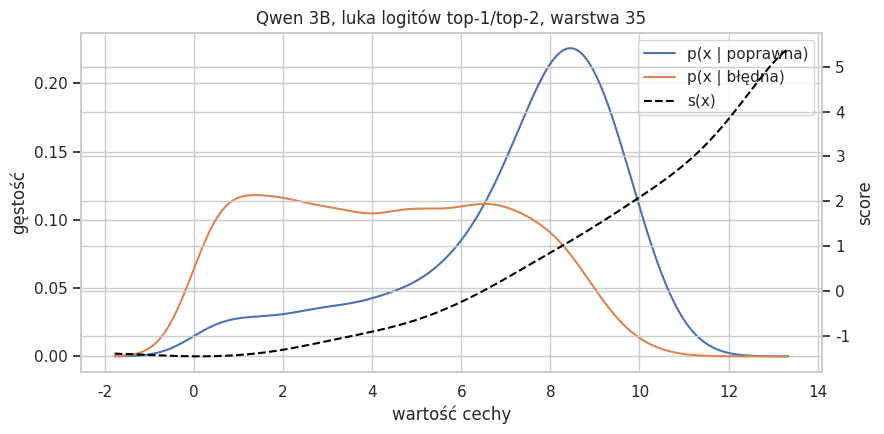

In [6]:
MODEL = 'Qwen 3B'
FEATURE = 'answer_choice_top1_top2_logit_gap'
run = next(run for run in runs if run['label'] == MODEL)
layer = int(run['selected'].query('feature_name == @FEATURE and selection_rank == 1')['layer_number'].iloc[0])
grid = run['grid'].query('feature_name == @FEATURE and layer_number == @layer').sort_values('grid_x')

fig, ax_density = plt.subplots(figsize=(9, 4.5))
ax_density.plot(grid['grid_x'], grid['p_good'], label='p(x | poprawna)')
ax_density.plot(grid['grid_x'], grid['p_bad'], label='p(x | błędna)')
ax_density.set(xlabel='wartość cechy', ylabel='gęstość')
ax_score = ax_density.twinx()
ax_score.plot(grid['grid_x'], grid['log_density_ratio'], color='black', ls='--', label='s(x)')
ax_score.set_ylabel('score')
handles = ax_density.get_lines() + ax_score.get_lines()
ax_density.legend(handles, [line.get_label() for line in handles])
ax_density.set_title(f'{MODEL}, {FEATURE_LABELS[FEATURE]}, warstwa {layer}')
plt.tight_layout()

## Diagnostyczna wartość `score` na zbiorze ewaluacyjnym

In [7]:
score_rows = []
for run in runs:
    selected = run['selected'].query('selection_rank <= 4')[['feature_name', 'layer_number']]
    values = run['eval_values'].merge(selected, on=['feature_name', 'layer_number'], how='inner')
    scored = attach_score_values(values, run['grid'])
    scored['model'] = run['label']
    score_rows.append(scored)
scores = apply_model_order(pd.concat(score_rows, ignore_index=True))
score_summary = scores.groupby(['model', 'feature', 'clean_is_correct'], observed=True).agg(
    mean_score=('log_density_ratio', 'mean'),
    supported_share=('is_supported', 'mean'),
    n=('example_id', 'size'),
).reset_index()
display(score_summary.round(3))

,model,feature,clean_is_correct,mean_score,supported_share,n
0,Qwen 0.5B,entropia odpowiedzi,False,-0.221,0.979,2240
1,Qwen 0.5B,entropia odpowiedzi,True,0.301,0.973,2644
2,Qwen 0.5B,luka logitów top-1/top-2,False,-0.189,0.999,2240
3,Qwen 0.5B,luka logitów top-1/top-2,True,0.325,0.978,2644
4,Qwen 0.5B,varentropy odpowiedzi,False,-0.053,0.979,2240
5,Qwen 0.5B,varentropy odpowiedzi,True,0.083,0.975,2644
6,Qwen 3B,entropia odpowiedzi,False,-0.640,0.957,964
7,Qwen 3B,entropia odpowiedzi,True,0.361,0.951,3920
8,Qwen 3B,luka logitów top-1/top-2,False,-0.516,0.973,964
9,Qwen 3B,luka logitów top-1/top-2,True,0.555,0.981,3920
